# Deep clustering of rain-induced noise: continuous monitoring

This notebook use well-trained DEC model (from the previous notebook) to get predictions on test data. 

**Content:** 
1. Load DEC model 
2. Test: Get predictions for all continuous data
3. Results: validate continous predictions with rainfall data and PSD

**Figures:**

This notebook is used to plot Figures 8 and 9 in the manuscript.

In [30]:
import os

import numpy as np
import pandas as pd

import torch
from torch import nn, optim

from model_DEC import autoencoder, DEC_net
from DEC_utils import get_stft_freq, switch_label, fft_taper, cal_energy
from scipy import signal
from scipy.signal import medfilt

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
import config as args
np.random.seed(0)
device = 'cpu' # Test is running on CPU with well-trained model
datadir = './data/'

In [3]:
from matplotlib.ticker import MultipleLocator,LogLocator,MaxNLocator, NullLocator
import matplotlib.gridspec as gridspec

font = {'size': 11}
plt.rc('font', **font)

In [4]:
import obspy

# 1. Load well-trained model

In [6]:
# load model 
DEC = DEC_net(args)
DEC.load_state_dict(torch.load('./results/model_weights/DEC_weights', map_location=device, weights_only=True))

<All keys matched successfully>

# 2. Test

## 2.1 Load spectrogram data to feed in ML model

In [7]:
def preprocess_input(data):
    from sklearn.preprocessing import StandardScaler
    # standarize data
    data = np.log(data)
    nsamples = data.shape[0]

    X = np.reshape(data, (nsamples, 76*56))
    scaler = StandardScaler()
    # scaler = MinMaxScaler(feature_range=(-1, 1))
    X = scaler.fit_transform(X.T).T
    X = np.reshape(X, (nsamples, 76, 56))
    data0 = X
    return data0

In [ ]:
data19 = np.load(datadir+'/DAS_spec/spec_359_jul21_aug21.npy')
data21 = np.load(datadir+'/DAS_spec/spec_359_2019.npy')

## 2.2 Predictions 

In [5]:
def predict_from_model(model, data, reorder=[0,3,1,2], device='cpu'):
    '''
    model: DEC model
    data: DAS spectrogram data
    reorder: reorder the output label to let 0->3 represents weak->strong 
    '''
    data_test = preprocess_input(data)
    d_test = torch.from_numpy(data_test).to(device).to(torch.float32)
    
    y_pred, _, _ = model(d_test)
    y = y_pred.max(1)[1].detach().cpu().numpy()
    y_after = switch_label(y, reorder)
    return y_after

In [ ]:
# predictions of 2019 data
y_2019 = predict_from_model(DEC, data19)
np.save(datadir+'predictions/prediction_2019.npy', y_2019)

In [ ]:
# predictions of 2021 data
y_2021 = predict_from_model(DEC, data21)
np.save(datadir+'predictions/prediction_2021.npy', y_2021)

# 3. Results

Load pre-saved prediction results 

In [31]:
# 2019
y1 = np.load(datadir+'predictions/20190618_prediction.npy')
y2 = np.load(datadir+'predictions/20190623_prediction.npy')
y3 = np.load(datadir+'predictions/201907_prediction.npy')
y4 = np.load(datadir+'predictions/20190801_prediction.npy')
y_2019 = np.concatenate([y1,y2,y3,y4])
y_2019 = medfilt(y_2019, kernel_size=3)

In [8]:
# 2021
y_2021 = np.load(datadir+'predictions/prediction_2021.npy')
y_2021 = medfilt(y_2021, kernel_size=3)

## 3.1 Load other resources for validation

### 3.1.1 Power Spectral Density (PSD) data

In [9]:
# 2019
psd_all1 = np.load(datadir+'DAS_psd/ch359_psd_201906_v3.npy')
psd_all2 = np.load(datadir+'DAS_psd/ch359_psd_201907_v3.npy')
psd_all3 = np.load(datadir+'DAS_psd/ch359_psd_201908_v3.npy')
psd_19 = np.concatenate([psd_all1, psd_all2, psd_all3], axis=0)
# 2021
psd_21 = np.load(datadir+'DAS_psd/Ch359_psd_0601_0930.npy')

In [10]:
# freq_psd: the frequency of psd data
from matplotlib import mlab
Fs = 250
divs_per_window = 13 
window_len = 60 # second
nfft = int(window_len / divs_per_window * Fs)
ovlp = 0.5
_, freq_psd = mlab.psd(np.ones(250*60), nfft, Fs, detrend=mlab.detrend_linear, window=fft_taper,
                          noverlap=int(ovlp * nfft), sides='onesided', scale_by_freq=True)

In [14]:
energy_19 = np.zeros(psd_19.shape[0])
for i in range(int(psd_19.shape[0])):
    # Freq domain
    spec = psd_19[i]
    spSumLow = cal_energy(freq_psd, spec, 1, 10)
    energy_19[i] = spSumLow

energy_21 = np.zeros(psd_21.shape[0])
for i in range(int(psd_21.shape[0])):
    # Freq domain
    spec = psd_21[i]
    spSumLow = cal_energy(freq_psd, spec, 1, 10)
    energy_21[i] = spSumLow

### 3.1.2 Rainfall rate data from the weather station

In [19]:
# 2019 
df_19 = pd.read_csv(datadir+'weather_data/rain_beaver_2019.csv',parse_dates=True,index_col=[1])
df_19 = df_19.resample('T').mean()
df_19.index = df_19.index + pd.DateOffset(hours=6) # convert to UTC
df_19['Rain Rate'] = df_19['Rain Rate'].interpolate()

# 2021
df_21 = pd.read_csv(datadir+'/weather_data/rain_beaver_2021.csv',parse_dates=True,index_col=[1])
df_21 = df_21.resample('T').mean()
df_21.index = df_21.index + pd.DateOffset(hours=4)
df_21['Rain Rate'] = df_21['Rain Rate'].interpolate()

## 3.2 Test results from continious data (2 weeks example)
Figure 7

### 3.2.1 from 07-15 to 07-31, 2019

In [16]:
x_dates = [x.strftime("%H") for x in 
               pd.date_range(start='2019-07-15',end='2019-07-17',freq='4H')]
y_dates = pd.date_range(start='2019-07-15', end='2019-07-31', freq='2D')

In [25]:
t0_2019 = obspy.UTCDateTime('201906180000')
start = obspy.UTCDateTime('201907150000')
end = obspy.UTCDateTime('201907310000')

i1 = int((start-t0_2019)/60)
i2 = int((end-t0_2019)/60)

y_after = y_2019[i1:i2]

In [27]:
df_sub = df_19[df_19.index.isin(pd.date_range(start=start.datetime,
                                    end=end.datetime,freq='T'))]
rain = df_sub['Rain Rate'].values

In [21]:
from matplotlib import colors
cmap = colors.ListedColormap(['lavenderblush','orange', 'limegreen', 'navy'])
# cmap = colors.ListedColormap(['lavenderblush', '#FFF3B0', '#C3E6CB', '#AFCBFF'])
bounds=[-0.5,0.5,1.5,2.5,3.5]
norm = colors.BoundaryNorm(bounds, cmap.N)

Text(0.5, 0, 'Hour')

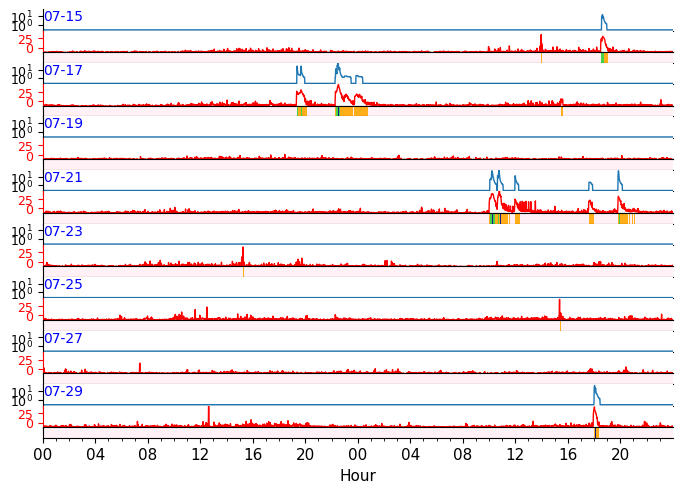

In [32]:
amp = energy_19[int((start-t0_2019)/60):int((end-t0_2019)/60)]

height_ratios = []
for i in range(8):
    height_ratios.append(2)  # for axs[2*i]
    height_ratios.append(2)  # for axs[2*i + 1]
    height_ratios.append(1)

fig, axs = plt.subplots(nrows=24, figsize=(7,5.1), gridspec_kw={"height_ratios": height_ratios},)

fig.subplots_adjust(left=0.05, bottom=0.1, right=0.95, top=0.94, hspace=0)
i1 = 0
window_row = 2880
for i in range(8):
    amp_2d = 10*np.log(amp[i1+i*window_row:i1+(i+1)*window_row])
    y_2d = y_after[i1+i*window_row:i1+(i+1)*window_row]
    axs[3*i].plot(rain[i1+i*window_row:i1+(i+1)*window_row]*25.4+0.254, lw=1)
    axs[3*i].spines['top'].set_visible(False)
    axs[3*i].spines['right'].set_visible(False)
    axs[3*i+1].spines['top'].set_visible(False)
    axs[3*i+1].spines['right'].set_visible(False)
    axs[3*i+2].spines['right'].set_visible(False)
    axs[3*i+1].plot(amp_2d, lw=1, c='r')
    axs[3*i+1].set_ylim(-12,45)
    axs[3*i+1].set_xlim([0, window_row])
    im = axs[3*i+2].imshow(y_2d.reshape([1, y_2d.size]), aspect='auto', interpolation='nearest', cmap=cmap, norm=norm, alpha=0.9)
    if i<7:
        axs[3*i+1].set_xticklabels([])
        axs[3*i+2].set_xticklabels([])
    axs[3*i+1].set_xticklabels([])
    axs[3*i+2].set_yticklabels([])
    # ax_twin = axs[i].twinx()
    # ax_twin.plot(rain[i1+i*2880:i1+(i+1)*2880]*25.4)
    # ax_twin.set_ylim([0, 120])
    axs[3*i].set_ylim([0.2, 60])
    axs[3*i].set_yscale('log')
    axs[3*i].set_xticklabels([])
    axs[3*i+2].set_yticks([])
    axs[3*i].yaxis.set_minor_locator(LogLocator(base=10, numticks=10))
    axs[3*i].tick_params(axis='y', labelsize=9)
    axs[3*i+1].tick_params(axis='y', labelsize=9)
    axs[3*i+1].spines['left'].set_color('r')
    axs[3*i+1].tick_params(axis='y', colors='r')
    # axs[2*i].yaxis.set_minor_locator(NullLocator())
    axs[3*i].set_xlim([0, window_row])
    # axs[2*i].set_ylabel(y_dates[i].strftime('%m-%d'), labelpad=-1)
    # axs[2*i+1].text(0, 0, 'Predictions', fontsize=10)
    # axs[2*i].text(0, 30, 'Precipitation', fontsize=10, c='b')
    axs[3*i].text(0, 3, y_dates[i].strftime('%m-%d'), fontsize=10, c='b')
axs[-1].xaxis.set(ticks=np.arange(0,2880,240),ticklabels=x_dates[:-1])
axs[-1].xaxis.set_minor_locator(MultipleLocator(60))
axs[-1].set_xlabel('Hour')

### 3.2.2 from 08-16 to 08-31, 2021

In [36]:
x_dates = [x.strftime("%H") for x in 
               pd.date_range(start='2019-08-16',end='2019-08-16',freq='4H')]
y_dates = pd.date_range(start='2021-08-16', end='2021-09-01', freq='2D')

In [37]:
t0_2021 = obspy.UTCDateTime('202106010000')
start = obspy.UTCDateTime('202108160000')
end = obspy.UTCDateTime('202109010000')

i1 = int((start-t0_2021)/60)
i2 = int((end-t0_2021)/60)

y_after = y_2021[i1:i2]

In [38]:
df_sub = df_21[df_21.index.isin(pd.date_range(start=start.datetime,
                                    end=end.datetime,freq='T'))]
rain = df_sub['Rain Rate'].values

Text(0.5, 0, 'Hour')

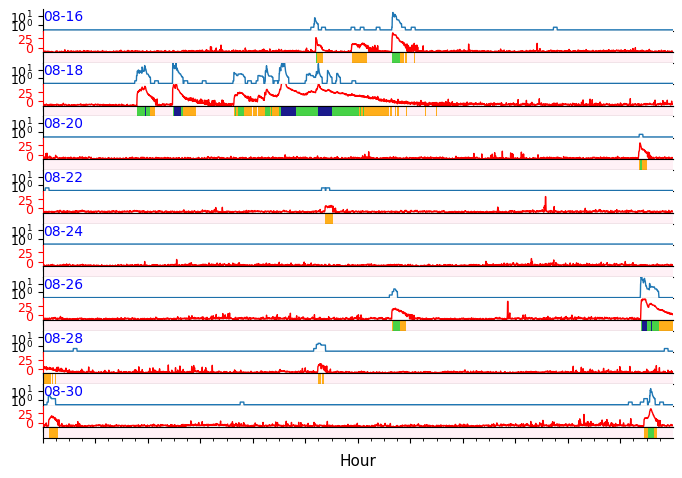

In [42]:
amp = energy_21[int((start-t0_2021)/60):int((end-t0_2021)/60)]

height_ratios = []
for i in range(8):
    height_ratios.append(2)  # for axs[2*i]
    height_ratios.append(2)  # for axs[2*i + 1]
    height_ratios.append(1)

fig, axs = plt.subplots(nrows=24, figsize=(7,5.1), gridspec_kw={"height_ratios": height_ratios},)

fig.subplots_adjust(left=0.05, bottom=0.1, right=0.95, top=0.94, hspace=0)
i1 = 0
window_row = 2880
for i in range(8):
    amp_2d = 10*np.log(amp[i1+i*window_row:i1+(i+1)*window_row])
    y_2d = y_after[i1+i*window_row:i1+(i+1)*window_row]
    axs[3*i].plot(rain[i1+i*window_row:i1+(i+1)*window_row]*25.4+0.254, lw=1)
    axs[3*i].spines['top'].set_visible(False)
    axs[3*i].spines['right'].set_visible(False)
    axs[3*i+1].spines['top'].set_visible(False)
    axs[3*i+1].spines['right'].set_visible(False)
    axs[3*i+2].spines['right'].set_visible(False)
    axs[3*i+1].plot(amp_2d, lw=1, c='r')
    axs[3*i+1].set_ylim(-12,45)
    axs[3*i+1].set_xlim([0, window_row])
    im = axs[3*i+2].imshow(y_2d.reshape([1, y_2d.size]), aspect='auto', interpolation='nearest', cmap=cmap, norm=norm, alpha=0.9)
    if i<7:
        axs[3*i+1].set_xticklabels([])
        axs[3*i+2].set_xticklabels([])
    axs[3*i+1].set_xticklabels([])
    axs[3*i+2].set_yticklabels([])
    # ax_twin = axs[i].twinx()
    # ax_twin.plot(rain[i1+i*2880:i1+(i+1)*2880]*25.4)
    # ax_twin.set_ylim([0, 120])
    axs[3*i].set_ylim([0.2, 60])
    axs[3*i].set_yscale('log')
    axs[3*i].set_xticklabels([])
    axs[3*i+2].set_yticks([])
    axs[3*i].yaxis.set_minor_locator(LogLocator(base=10, numticks=10))
    axs[3*i].tick_params(axis='y', labelsize=9)
    axs[3*i+1].tick_params(axis='y', labelsize=9)
    axs[3*i+1].spines['left'].set_color('r')
    axs[3*i+1].tick_params(axis='y', colors='r')
    # axs[2*i].yaxis.set_minor_locator(NullLocator())
    axs[3*i].set_xlim([0, window_row])
    # axs[2*i].set_ylabel(y_dates[i].strftime('%m-%d'), labelpad=-1)
    # axs[2*i+1].text(0, 0, 'Predictions', fontsize=10)
    # axs[2*i].text(0, 30, 'Precipitation', fontsize=10, c='b')
    axs[3*i].text(0, 3, y_dates[i].strftime('%m-%d'), fontsize=10, c='b')
axs[-1].xaxis.set(ticks=np.arange(0,2880,240),ticklabels=x_dates[:-1])
axs[-1].xaxis.set_minor_locator(MultipleLocator(60))
axs[-1].set_xlabel('Hour')

## 3.3 Light rain example
Figure 8

In [43]:
# Time window
t0_2019 = obspy.UTCDateTime('201906180000')
start = obspy.UTCDateTime('201908021900')
end = obspy.UTCDateTime('201908022200')
i1 = int((start-t0_2019)/60)
i2 = int((end-t0_2019)/60)
all_dates = pd.date_range(start=start.datetime, end=end.datetime, freq='T')

In [45]:
# waveform
D359 = obspy.read(datadir+'/DAS_waveform/ch359_20190801.sac')
D359 = D359.copy().filter('lowpass', freq=126, corners=8)
D359 = D359.decimate(2, no_filter=True)
D = D359.copy().trim(starttime=start, endtime=end+0.004)

In [46]:
# Cut psd, predictions, and rainfall data
psd = psd_19[i1:i2]
y_after = y_2019[i1:i2+1]

df_sub = df_19[df_19.index.isin(pd.date_range(start=start.datetime,
                                    end=end.datetime,freq='T'))]
rain = df_sub['Rain Rate'].values[:-1]

Text(0, 0.5, 'Predicted labels')

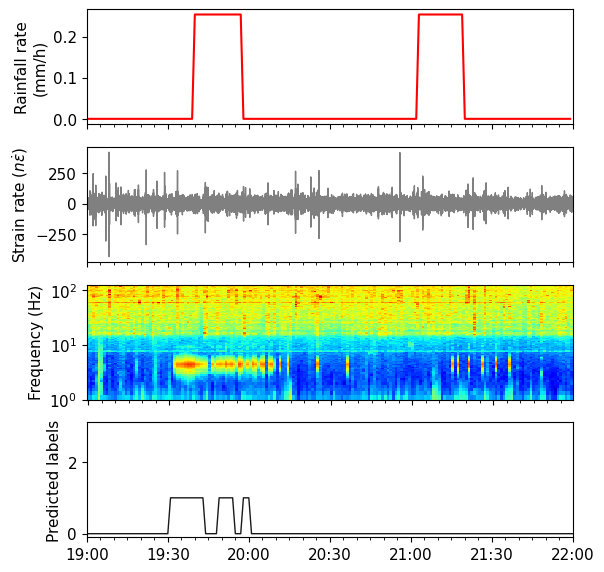

In [47]:
fig, axes = plt.subplots(ncols=1, nrows=4, figsize=(6,6))
fig.subplots_adjust(left=0.15, bottom=0.08, right=0.96, top=0.96, hspace=0.2)
axes[0].plot(rain*25.4, c='r')
axes[0].set_ylabel('Rainfall rate\n(mm/h)')
axes[0].set_xlim([0,rain.size])
axes[0].xaxis.set_major_locator(MultipleLocator(30))
axes[0].xaxis.set_minor_locator(MultipleLocator(5))
axes[0].set_xticklabels([])

axes[1].plot(D[0].data, lw=1, c='gray')
axes[1].set_ylabel('Strain rate ($n\dot{\epsilon}$)')
axes[1].xaxis.set_major_locator(MultipleLocator(30*60*250))
axes[1].xaxis.set_minor_locator(MultipleLocator(5*60*250))
axes[1].set_xticklabels([])
axes[1].set_xlim([0, D[0].data.size])

axes[2].pcolormesh(np.arange(0,psd.shape[0]), freq_psd+freq_psd[1]-freq_psd[0], 10*np.log(psd.T), cmap=plt.get_cmap('jet'), shading='auto')
axes[2].set_yscale('log')
axes[2].set_ylim([1,125])
axes[2].xaxis.set_major_locator(MultipleLocator(30))
axes[2].xaxis.set_minor_locator(MultipleLocator(5))
axes[2].yaxis.set_major_locator(LogLocator(base=10, numticks=30))
axes[2].yaxis.set_minor_locator(LogLocator(base=10, numticks=10))
axes[2].set_xticklabels([])
axes[2].set_ylabel('Frequency (Hz)')

label_dates = [x.strftime("%m-%d %H:%M") for x in 
               pd.date_range(start='2021-08-18 00:00',end='2021-08-19 11:00', freq='6H')]

axes[3].plot(all_dates, y_after, lw=1, c='k', alpha=0.9)
# axes[3].xaxis.set(ticks=np.arange(0,y_after.shape[0],6*60),ticklabels=label_dates)
axes[3].set_xlim([all_dates[0],all_dates[-1]])
axes[3].set_ylim([-0.1,3.1])
# axes[3].tick_params(axis='x', labelrotation = 15)
axes[3].xaxis.set_minor_locator(mdates.MinuteLocator(interval=5))
axes[3].xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
# axes[3].yaxis.set_major_locator(MultipleLocator(1))
# axe[3].set_yticklabels([])
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[3].set_ylabel('Predicted labels')
# axes[4].tick_params(axis='x',which='major',direction='out',length=5,width=1.4)
# plt.tight_layout()
# plt.savefig('fig9.png', dpi=300)